# 🏠 House Price Prediction — Exploratory Data Analysis (EDA)

This notebook is designed to **teach EDA step-by-step** with clear reasoning.

---
## Objectives
- Understand the dataset structure
- Identify data quality issues
- Explore feature distributions and relationships
- Detect leakage, multicollinearity, and outliers
- Make data-driven decisions before modeling


In [ ]:
# %pip install pandas numpy matplotlib seaborn

In [9]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')  # Sets the style of the plots
df = pd.read_csv('house_price_eda_dataset.csv')
df.head()  # Shows only 5 values by default

,house_id,area_sqft,bedrooms,bathrooms,floors,age_years,location,house_condition,distance_city_center,crime_rate,avg_income_area,parking_spaces,has_garden,near_school,noise_level,seller_type,hoa_fee,price,listing_price
0,1,2098,1,3,1,76,Suburban,5,0.500000,11.327435,108827.590191,1,1,0,38.722569,Builder,543.537415,516376.740139,548756.632050
1,2,1717,3,3,1,40,Urban,4,16.267894,33.181698,45565.984820,2,0,1,43.808368,Owner,396.613959,415533.681422,429948.442260
2,3,2188,5,2,1,52,Semi-Urban,4,6.461800,NaN,86311.406680,1,0,1,46.939885,Owner,110.027914,511167.998213,464827.538490
3,4,2713,3,3,2,49,Suburban,3,7.506715,12.702482,88585.878425,1,0,0,32.286637,Owner,182.151270,611320.875584,644093.599319
4,5,1659,4,2,3,14,Urban,3,20.937104,20.788933,99320.405548,2,1,1,58.951137,Owner,47.208461,421723.317703,424634.634045


## 1️⃣ Dataset Overview

We begin by understanding the **shape, data types, and memory footprint** of the dataset.

In [ ]:
df.shape # Shows the shape of the dataframe which is total rows and columns

(1200, 19)

In [ ]:
df.info() # Shows the data types and non-null counts of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              1200 non-null   int64  
 1   area_sqft             1200 non-null   int64  
 2   bedrooms              1200 non-null   int64  
 3   bathrooms             1200 non-null   int64  
 4   floors                1200 non-null   int64  
 5   age_years             1200 non-null   int64  
 6   location              1200 non-null   object 
 7   house_condition       1200 non-null   int64  
 8   distance_city_center  1200 non-null   float64
 9   crime_rate            1140 non-null   float64
 10  avg_income_area       1200 non-null   float64
 11  parking_spaces        1200 non-null   int64  
 12  has_garden            1200 non-null   int64  
 13  near_school           1200 non-null   int64  
 14  noise_level           1200 non-null   float64
 15  seller_type          

## 2️⃣ Missing Value Analysis

Missing data may indicate **data collection issues** or **real-world absence**.
We must quantify and inspect patterns before deciding how to handle them.

In [14]:
# show columns with missing values
df.isnull().sum()

house_id                 0
area_sqft                0
bedrooms                 0
bathrooms                0
floors                   0
age_years                0
location                 0
house_condition          0
distance_city_center     0
crime_rate              60
avg_income_area          0
parking_spaces           0
has_garden               0
near_school              0
noise_level              0
seller_type              0
hoa_fee                 96
price                    0
listing_price            0
dtype: int64

In [ ]:
# “Which columns have the most missing data, and how bad is it?”
# mean = (number of missing values) / (total rows) 
# Shows the percentage of missing values in each column

df.isnull().mean().sort_values(ascending=False) 


house_id                0.00
seller_type             0.00
noise_level             0.00
near_school             0.00
has_garden              0.00
parking_spaces          0.00
avg_income_area         0.00
price                   0.00
listing_price           0.00
house_condition         0.00
location                0.00
age_years               0.00
floors                  0.00
bathrooms               0.00
bedrooms                0.00
area_sqft               0.00
distance_city_center    0.00
crime_rate              0.05
hoa_fee                 0.08
dtype: float64

## 3️⃣ Target Variable Analysis — Price

The target variable drives modeling decisions. We inspect its **distribution, skewness, and outliers**.

Step 1: Create price bins (ranges)

In [26]:
price_bins = pd.cut(
    df['price'],
    bins=10
)

Step 2: Count how many houses fall in each range

In [27]:
price_distribution_table = price_bins.value_counts().sort_index()
price_distribution_table


price
(60687.646, 152715.472]      18
(152715.472, 243832.131]     77
(243832.131, 334948.79]     162
(334948.79, 426065.449]     285
(426065.449, 517182.108]    276
(517182.108, 608298.767]    240
(608298.767, 699415.426]     96
(699415.426, 790532.084]     31
(790532.084, 881648.743]     13
(881648.743, 972765.402]      2
Name: count, dtype: int64

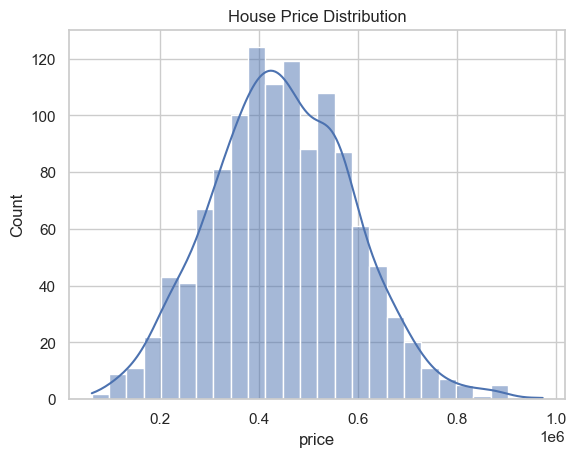

In [18]:
plt.figure()
sns.histplot(df['price'], kde=True)
plt.title('House Price Distribution')
plt.show()

📌 **Inference:** Price is right-skewed, indicating that a log transformation may help linear models.

# 📊 Understanding House Price Distribution  
*(Using Histogram + Table)*

---

## 1️⃣ What are we trying to understand here?

Before building any model, we ask:

> **How are house prices spread across the dataset?**

This helps us understand:
- Where most data lies  
- Whether extreme values exist  
- Whether the target variable behaves “normally” or not  

---

## 2️⃣ What does the Histogram show?

From the graph, we observe:

- Most house prices are concentrated between **~250k and ~600k**
- The bars are tallest in the **middle price ranges**
- As price increases beyond **~600k**, the number of houses drops sharply
- A **long tail extends toward higher prices (right side)**

📌 This visual shape indicates that the data is **not symmetric**.

---

## 3️⃣ What does the Table show?

The table is the **numerical representation of the histogram**.

| Price Range | Count |
|------------|------|
| 60k – 150k | 18 |
| 150k – 240k | 77 |
| 240k – 335k | 162 |
| 335k – 426k | 285 |
| 426k – 517k | 276 |
| 517k – 608k | 240 |
| 608k – 699k | 96 |
| 699k – 790k | 31 |
| 790k – 881k | 13 |
| 881k – 973k | 2 |

---

## 4️⃣ How do we read this table logically?

### Step-by-step reasoning:

### 🔹 Step 1: Identify where counts are highest
- Maximum number of houses fall in the **mid-price ranges (335k–608k)**
- This represents the **majority of the dataset**

### 🔹 Step 2: Observe the trend as price increases
- House counts steadily decrease as prices increase
- Very few houses exist in the highest price ranges

### 🔹 Step 3: Recognize the imbalance
- Many houses at lower and middle prices  
- Very few houses at extremely high prices  

📌 This imbalance is the key insight.

---

## 5️⃣ What does “right-skewed” mean here?

> **A distribution is right-skewed when most values are lower, and a few very large values stretch the distribution toward the right.**

In this dataset:
- Lower prices → high frequency  
- Higher prices → low frequency but long tail  

Both the **histogram** and the **table** confirm this pattern.

---

## 6️⃣ Why is this important for Machine Learning?

Most regression models (especially **Linear Regression**) assume:
- Errors are evenly distributed  
- Target variable is approximately symmetric  

In right-skewed data:
- Extreme values dominate error calculations  
- Models focus too much on rare expensive houses  
- Predictions for typical houses become less accurate  

---

## 7️⃣ Why does log transformation help?

Applying a log transformation:
- Compresses large price values  
- Reduces the impact of extreme prices  
- Makes the distribution more symmetric  

As a result:
- The model learns balanced patterns  
- Prediction stability improves  

---

## 8️⃣ Final Logical Chain

1. Histogram shows a long tail on the right  
2. Table confirms fewer houses at higher prices  
3. This indicates a right-skewed distribution  
4. Right-skew violates linear model assumptions  
5. Log transformation reduces skewness  
6. Therefore, applying `log(price)` may improve model performance  

---

## 📌 Final Inference

> **Price is right-skewed, meaning most houses fall in lower-to-mid price ranges while a few very expensive houses stretch the distribution toward higher values. Applying a log transformation can reduce this imbalance and help linear models learn more effectively.**

---

## 🎓 One-Line Summary

> *The graph shows the shape, the table validates it numerically, and together they explain why the price distribution is right-skewed.*


## 4️⃣ Univariate Analysis — Numerical Features

We inspect individual feature distributions to detect skewness, outliers, and scaling needs.

## 2️⃣ What does each statistic mean? (With Formulas)

This table explains **what each statistic represents** and **how it is mathematically calculated**.

| Statistic | Meaning | Formula / How It Is Calculated |
|---------|--------|--------------------------------|
| **count** | Number of non-missing values | `count = n` (total values − missing values) |
| **mean** | Average value | `mean = (x₁ + x₂ + ... + xₙ) / n` |
| **std** | Spread of the data | `std = √( Σ(xᵢ − mean)² / n )` |
| **min** | Smallest value | `min = smallest(x₁, x₂, ..., xₙ)` |
| **25% (Q1)** | First quartile | Value at position `0.25 × (n + 1)` after sorting |
| **50% (Median / Q2)** | Middle value | If `n` is odd → middle value; if even → `(xₙ/2 + xₙ/2+1) / 2` |
| **75% (Q3)** | Third quartile | Value at position `0.75 × (n + 1)` after sorting |
| **max** | Largest value | `max = largest(x₁, x₂, ..., xₙ)` |

---

### 📌 Notes 

- **count** tells us *data availability*
- **mean vs median** helps detect *skewness*
- **std** measures *variability* (higher = more spread)
- **quartiles** divide data into *four equal parts*
- **min/max** help detect *outliers or invalid values*

---

### 🎓 One-Line  Takeaway

> *These statistics summarize how many values we have, where they center, how far they spread, and how extreme they get.*


In [29]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
house_id,1200.0,600.500000,346.554469,1.000000,300.750000,600.500000,900.250000,1.200000e+03
area_sqft,1200.0,1824.216667,588.546145,400.000000,1424.750000,1828.500000,2204.750000,4.111000e+03
bedrooms,1200.0,2.930000,1.113313,1.000000,2.000000,3.000000,4.000000,5.000000e+00
bathrooms,1200.0,2.305000,0.890301,1.000000,2.000000,2.000000,3.000000,4.000000e+00
floors,1200.0,1.472500,0.660510,1.000000,1.000000,1.000000,2.000000,3.000000e+00
age_years,1200.0,40.480000,23.142910,0.000000,21.000000,41.000000,60.250000,7.900000e+01
house_condition,1200.0,3.373333,1.073118,1.000000,3.000000,3.000000,4.000000,5.000000e+00
distance_city_center,1200.0,7.807295,7.627560,0.500000,2.343543,5.512952,10.680337,4.000000e+01
crime_rate,1140.0,28.359764,16.001650,0.623554,15.774801,26.322600,38.004349,8.307752e+01
avg_income_area,1200.0,84565.037216,24634.676266,30000.000000,67127.802066,84438.969444,101268.160272,1.607273e+05


## 5️⃣ Categorical Feature Distribution

Understanding category frequency helps identify **rare levels** and encoding strategies.

In [33]:
df['location'].value_counts(normalize=False)

location
Urban         463
Suburban      447
Semi-Urban    183
Rural         107
Name: count, dtype: int64

Most houses are located in Urban and Suburban areas, while Rural houses form a small portion of the dataset. The presence of a rare category indicates the need for careful handling and encoding during modeling.

## 6️⃣ Bivariate Analysis — Area vs Price

We explore relationships between predictors and the target variable.

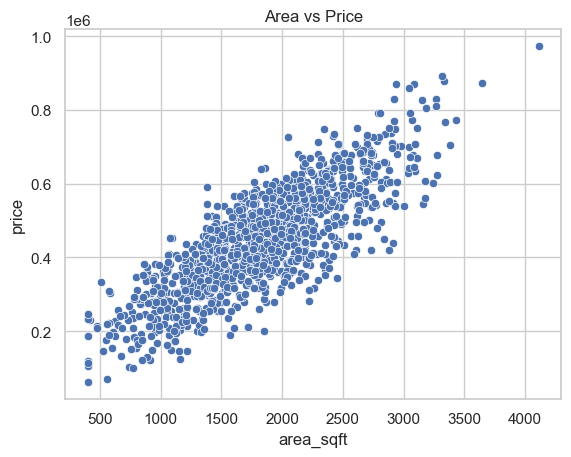

In [31]:
plt.figure()
sns.scatterplot(x='area_sqft', y='price', data=df)
plt.title('Area vs Price')
plt.show()

📌 **Inference:** Larger area generally leads to higher prices, confirming domain intuition.

House area and price show a strong positive relationship, indicating that larger houses generally have higher prices. While area is a key predictor, variation in prices for similar-sized houses suggests that additional factors also influence price.

## 7️⃣ Correlation & Multicollinearity

Correlation analysis helps detect redundant predictors.

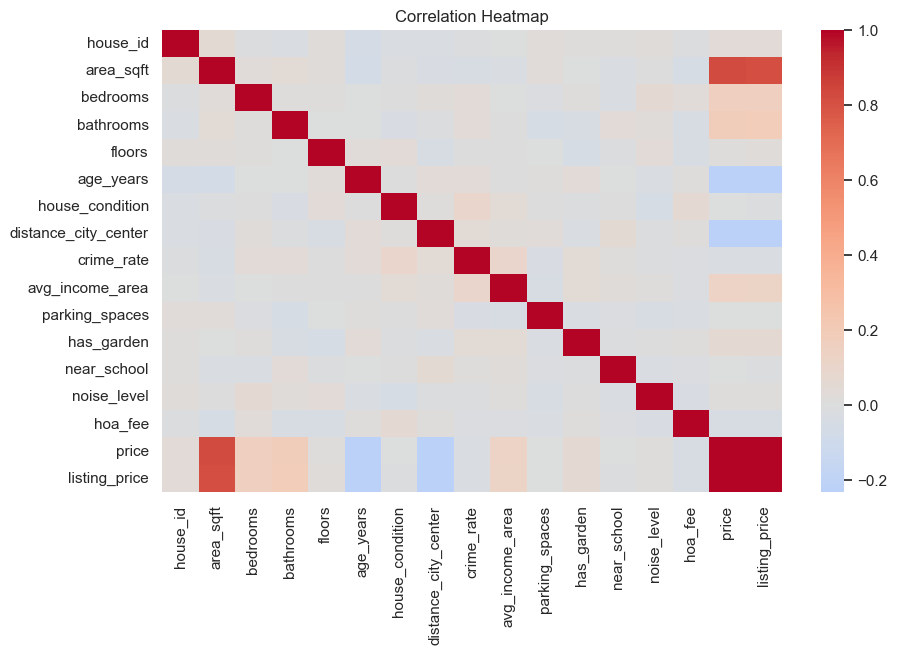

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# 🔥 Correlation Heatmap — What Are We Inferring?

---

## 1️⃣ What are we trying to understand here?

At this stage of EDA, we are asking:

> **How strongly are numerical features related to each other and to the target (price)?**

This helps us:
- Identify **important predictors**
- Detect **redundant features**
- Spot **data leakage**
- Decide which features to keep, drop, or transform

---

## 2️⃣ What does this heatmap represent?

This heatmap shows **pairwise correlation values** between numerical columns.

- Each cell represents a **correlation coefficient**
- Values range from **-1 to +1**

### Color meaning:
- 🔴 **Red** → strong positive correlation  
- 🔵 **Blue** → strong negative correlation  
- ⚪ **Light / near white** → weak or no correlation  

---

## 3️⃣ How should we read this heatmap?

### Rule of thumb:
- Focus on the **price row (or column)**
- Look for **strong colors**
- Ignore the diagonal (self-correlation = 1)

---

## 4️⃣ Key Inferences with Respect to `price`

### 🟢 Strong Positive Correlations

#### `area_sqft` → `price`
- Dark red color
- Strong positive correlation

📌 **Inference:**  
Larger houses tend to have higher prices.  
This confirms our earlier scatter plot analysis.

---

#### `listing_price` → `price`
- Almost perfect correlation (deep red)

📌 **Inference:**  
⚠️ **Data leakage detected**  
`listing_price` is derived from `price` and must be **removed before modeling**.

---

### 🟡 Moderate Positive Correlations

#### `bedrooms`, `bathrooms`
- Light-to-moderate red shades

📌 **Inference:**  
These features contribute to price but are not as strong as area.

---

#### `avg_income_area`
- Mild positive correlation

📌 **Inference:**  
Socioeconomic conditions influence house prices.

---

### 🔵 Negative Correlations

#### `age_years` → `price`
- Light blue shade

📌 **Inference:**  
Older houses generally cost less.

---

#### `distance_city_center` → `price`
- Negative correlation

📌 **Inference:**  
Houses farther from the city center tend to be cheaper.

---

## 5️⃣ Feature Inter-Correlations (Multicollinearity)

### Example:
- `bedrooms` and `bathrooms` show positive correlation
- `area_sqft` may correlate with both

📌 **Inference:**  
Some features provide overlapping information.  
This can cause **multicollinearity**, especially in linear models.

---

## 6️⃣ What does weak correlation mean?

Features like:
- `has_garden`
- `near_school`
- `noise_level`

show weak or near-zero correlation with price.

📌 **Inference:**  
These features may still be useful:
- In combination with others
- In non-linear models (trees, ensembles)

Low correlation ≠ useless feature.

---

## 7️⃣ What are we NOT concluding from this heatmap?

Important clarifications:
- Correlation ≠ causation
- Non-linear relationships may not appear here
- Categorical features are not included

---

## 8️⃣ Why is this step critical before modeling?

This heatmap helps us:
- Select **strong predictors**
- Remove **leakage features**
- Identify **redundant variables**
- Decide whether regularization is needed

---

## 📌 Final Inference

> **House price is strongly influenced by area and listing price (leakage), moderately influenced by bedrooms, bathrooms, and income level, and negatively influenced by age and distance from the city center. The presence of highly correlated features indicates the need for careful feature selection and multicollinearity handling before modeling.**

---

## 🎓 One-Line Summary

> *The correlation heatmap shows which features move together, which truly matter for price, and which may mislead our model if left unchecked.*


## 8️⃣ Leakage Detection

`listing_price` is highly correlated with `price` and must be removed before modeling.

## 9️⃣ EDA Summary & Decisions

**Based on EDA, we will:**
- Drop identifiers and leakage features
- Handle missing values carefully
- Transform skewed variables
- Select features with strong signal

EDA is complete. Modeling comes next.